In [1]:
import Pkg; Pkg.add("DifferentialEquations")
import Pkg; Pkg.add("GLMakie")
import Pkg; Pkg.add("Plots")
import Pkg; Pkg.add("Trapz")

  Installing known registries into `~/.julia`
       Added `General` registry to ~/.julia/registries
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed x265_jll ──────────────────────────── v4.1.0+0
   Installed libdecor_jll ──────────────────────── v0.2.2+0
   Installed libfdk_aac_jll ────────────────────── v2.0.4+0
   Installed JpegTurbo_jll ─────────────────────── v3.1.3+0
   Installed DifferentialEquations ─────────────── v7.17.0
   Installed Libmount_jll ──────────────────────── v2.41.1+0
   Installed OrdinaryDiffEqRKN ─────────────────── v1.10.0
   Installed OrdinaryDiffEqStabilizedRK ────────── v1.8.0
   Installed GR_jll ────────────────────────────── v0.73.17+0
   Installed SciMLPublic ───────────────────────── v1.0.1
   Installed LERC_jll ──────────────────────────── v4.0.1+0
   Installed StatsFuns ─────────────────────────── v1.5.2
   Installed Preferences ───────────────────────── v1.5.0
   Installed OrdinaryDiffEqRosenb

In [2]:
using Pkg
using GLMakie  # opens a native OS window with full interactivity
using Plots
using DifferentialEquations
using Trapz

Pkg.activate(joinpath(homedir(), "plotting_environment"))

  Activating new project at `~/plotting_environment`


In [3]:
function energy(n,L; hbar = 1, M = 1)
    return n^2*hbar^2*pi^2/(2*M*L^2)
end

function phase(ts,es;hbar=1)
    return exp(-1im/hbar*trapz(ts, es))
end

function overlap(beta, alpha)
    return (alpha == beta) ? - 0.5 : 2*alpha*beta/(alpha^2-beta^2) * (-1)^(alpha+beta)
end

overlap (generic function with 1 method)

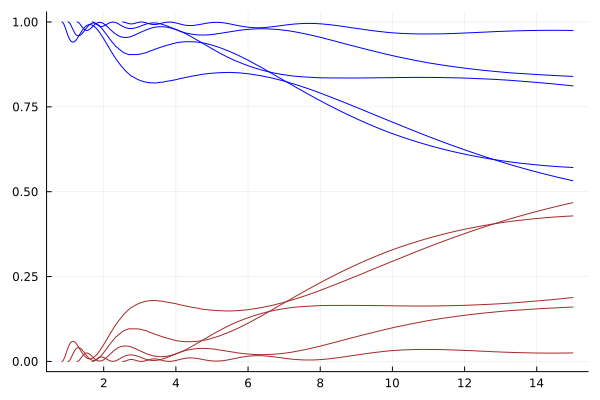

"/Users/gab/Library/Mobile Documents/com~apple~CloudDocs/QuIST/QuSimulation/julia_playground/evolution.png"

In [6]:
function f!(da, a, p, t)
    t0, v = p
    hbar, L0  = 1, 1
    dt = 0.01
    ts = t0:dt:t

    Lt = v.*ts
    es12 = [energy(2,Ls)-energy(1,Ls) for Ls in Lt]
    es21 = [energy(1,Ls)-energy(2,Ls) for Ls in Lt]

    da[2] = overlap(2,1)/t * a[1]* phase(ts, es21)
    da[1] = overlap(1,2)/t * a[2]* phase(ts, es12)
end
  
function t_start(;L0, v)
    return (L0/v, v)
end

function plot_evolution(p;L0=1, v=0.5, a0 = ComplexF64[1.0, 0.0], tn=15)
    t0 = 1.01*t_start(L0=L0, v=v)[1]
    tspan = (t0, tn)
    prob = ODEProblem(f!, a0, tspan, t_start(L0=L0, v=v))

    sol = solve(prob, saveat=0.01);
    Plots.plot!(p, sol.t, abs.(sol[1,:]).^2, color = "blue")
    Plots.plot!(p, sol.t, abs.(sol[2,:]).^2, color = "brown")
    #Plots.plot!(p, sol.t, abs.(sol[1,:]).^2+abs.(sol[2,:]).^2, label = "P_total")
    return p
end

p = Plots.plot(legend=false)
vs = [0.2*i for i in 2:6]
for v in vs
    p = plot_evolution(p, v=v)
end
display(p)
savefig(p, "evolution.png")

In [56]:
L0 = 1
tn = 20
v_min = L0/tn

fig = GLMakie.Figure()
ax = GLMakie.Axis(fig[1,1], xlabel="t", ylabel="Probability")
sl = GLMakie.Slider(fig[2,1], range=v_min:0.01:2, startvalue=0.5)
GLMakie.Label(fig[2,2], GLMakie.lift(v -> "v = $(round(v, digits=2))", sl.value))

GLMakie.on(sl.value) do v
    GLMakie.empty!(ax)
    t0 = 1.01 * t_start(L0=L0, v=v)[1]
    prob = ODEProblem(f!, ComplexF64[1.0, 0.0], (t0, tn), t_start(L0=L0, v=v))
    sol = solve(prob, saveat=0.1)

    t_pre = collect(0.0:0.1:t0-0.1)
    t_full = vcat(t_pre, sol.t)
    p1 = vcat(ones(length(t_pre)),  abs.(sol[1,:]).^2)
    p2 = vcat(zeros(length(t_pre)), abs.(sol[2,:]).^2)

    GLMakie.lines!(ax, t_full, p1, label = "P(|1>)")
    GLMakie.lines!(ax, t_full, p2, label = "P(|2>)")
    GLMakie.vlines!(ax, t0, color=:black, linestyle=:dash, label = "t0")
    GLMakie.xlims!(ax, 0, tn)
    GLMakie.ylims!(ax, 0, 1.)
    GLMakie.axislegend(ax)
end
GLMakie.notify(sl.value)
display(fig)


GLMakie.Screen(...)